ALGORITMO GENÉTICO PASSO A PASSO

População inicial: [[1, 0, 0, 0, 1], [1, 1, 1, 0, 0], [1, 0, 1, 1, 1], [0, 0, 1, 0, 0], [0, 1, 1, 0, 0], [1, 0, 0, 1, 0]]

==================== GERAÇÃO 0 ====================

Avaliação dos indivíduos:
  [1, 0, 0, 0, 1] → x=17 → f(x)=289
  [1, 1, 1, 0, 0] → x=28 → f(x)=784
  [1, 0, 1, 1, 1] → x=23 → f(x)=529
  [0, 0, 1, 0, 0] → x= 4 → f(x)= 16
  [0, 1, 1, 0, 0] → x=12 → f(x)=144
  [1, 0, 0, 1, 0] → x=18 → f(x)=324

 Melhor: x = 28 → f(x) = 784

==================== GERAÇÃO 1 ====================

Avaliação dos indivíduos:
  [1, 1, 1, 0, 0] → x=28 → f(x)=784
  [1, 1, 1, 0, 0] → x=28 → f(x)=784
  [1, 1, 1, 0, 0] → x=28 → f(x)=784
  [0, 0, 1, 1, 1] → x= 7 → f(x)= 49
  [1, 1, 0, 0, 1] → x=25 → f(x)=625
  [1, 0, 0, 1, 0] → x=18 → f(x)=324

 Melhor: x = 28 → f(x) = 784

==================== GERAÇÃO 2 ====================

Avaliação dos indivíduos:
  [1, 1, 1, 0, 0] → x=28 → f(x)=784
  [1, 1, 1, 0, 0] → x=28 → f(x)=784
  [1, 1, 1, 0, 0] → x=28 → f(x)=784
  [1

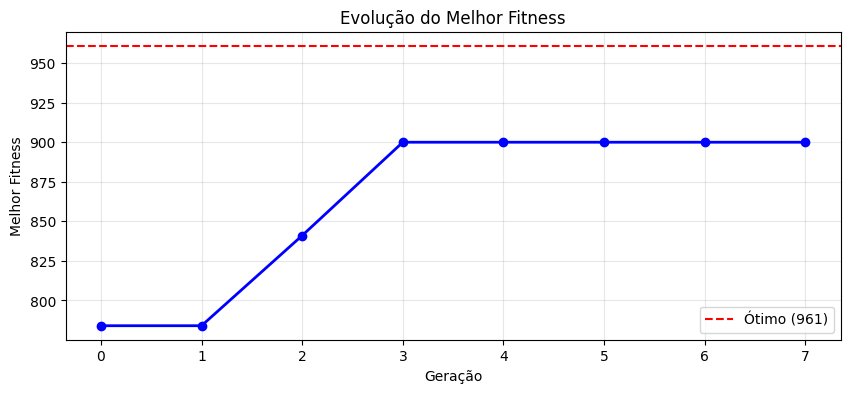

In [1]:
#DEMONSTRAÇÃO: Algoritmo Genético
#Problema: Encontrar x que maximiza f(x) = x² no intervalo [0, 31]
#Representação: Binário (5 bits)

import numpy as np
import matplotlib.pyplot as plt
import random

# CONFIGURAÇÕES
POP_SIZE = 6
BITS = 5
GERACOES = 8
TAXA_MUTACAO = 0.1

# FUNÇÕES
def binario_para_decimal(bits):
    """Converte lista de bits para número."""
    valor = 0
    for i, bit in enumerate(reversed(bits)):
        valor += bit * (2 ** i)
    return valor

def fitness(x):
    """Função objetivo: f(x) = x²."""
    return x ** 2

def criar_populacao():
    """Cria 6 indivíduos aleatórios de 5 bits."""
    populacao = []
    for _ in range(POP_SIZE):
        individuo = [random.randint(0, 1) for _ in range(BITS)]
        populacao.append(individuo)
    return populacao

def selecao_roleta(populacao, fitnesses):
    """Escolhe um indivíduo baseado no fitness (quanto maior, mais chance)."""
    total = sum(fitnesses)
    if total == 0:
        return random.choice(populacao)

    escolha = random.uniform(0, total)
    acumulado = 0
    for i, ind in enumerate(populacao):
        acumulado += fitnesses[i]
        if acumulado > escolha:
            return ind

    return populacao[-1]

def crossover(pai1, pai2):
    """Mistura dois pais em um ponto."""
    ponto = random.randint(1, BITS - 1)
    filho1 = pai1[:ponto] + pai2[ponto:]
    filho2 = pai2[:ponto] + pai1[ponto:]
    return filho1, filho2

def mutacao(individuo):
    """Altera um bit aleatoriamente."""
    for i in range(len(individuo)):
        if random.random() < TAXA_MUTACAO:
            individuo[i] = 1 - individuo[i]
    return individuo

# ==================== ALGORITMO PRINCIPAL ====================
print("=" * 50)
print("ALGORITMO GENÉTICO PASSO A PASSO")
print("=" * 50)

# Passo 1: Criar população inicial
populacao = criar_populacao()
print(f"\nPopulação inicial: {populacao}")

historico_melhor = []

for geracao in range(GERACOES):
    print(f"\n{'='*20} GERAÇÃO {geracao} {'='*20}")

    # Passo 2: Avaliar (calcular fitness)
    fitnesses = []
    for ind in populacao:
        x = binario_para_decimal(ind)
        fit = fitness(x)
        fitnesses.append(fit)

    # Mostrar avaliação
    print("\nAvaliação dos indivíduos:")
    for i, ind in enumerate(populacao):
        x = binario_para_decimal(ind)
        print(f"  {ind} → x={x:2d} → f(x)={x*x:3d}")

    melhor_fit = max(fitnesses)
    melhor_idx = fitnesses.index(melhor_fit)
    melhor_x = binario_para_decimal(populacao[melhor_idx])
    print(f"\n Melhor: x = {melhor_x} → f(x) = {melhor_fit}")
    historico_melhor.append(melhor_fit)

    # Passo 3: Elitismo (guardar o melhor)
    nova_populacao = [populacao[melhor_idx].copy()]

    # Passo 4: Criar filhos (crossover + mutação)
    while len(nova_populacao) < POP_SIZE:
        # Selecionar pais
        pai1 = selecao_roleta(populacao, fitnesses)
        pai2 = selecao_roleta(populacao, fitnesses)

        # Cruzar
        filho1, filho2 = crossover(pai1, pai2)

        # Mutar
        filho1 = mutacao(filho1)
        filho2 = mutacao(filho2)

        nova_populacao.append(filho1)
        if len(nova_populacao) < POP_SIZE:
            nova_populacao.append(filho2)

    populacao = nova_populacao

# ==================== RESULTADO FINAL ====================
print("\n" + "=" * 50)
print("RESULTADO FINAL")
print("=" * 50)

# Avaliar população final
fitnesses_final = []
for ind in populacao:
    x = binario_para_decimal(ind)
    fitnesses_final.append(fitness(x))

melhor_idx = fitnesses_final.index(max(fitnesses_final))
melhor_x = binario_para_decimal(populacao[melhor_idx])
melhor_fit = max(fitnesses_final)

print(f"\nMelhor indivíduo: {populacao[melhor_idx]}")
print(f"x = {melhor_x}")
print(f"f(x) = {melhor_fit}")
print(f"\nÓtimo global: x = 31, f(x) = 961")
print(f"Erro: {961 - melhor_fit}")

# Gráfico
plt.figure(figsize=(10, 4))
plt.plot(range(GERACOES), historico_melhor, 'bo-', linewidth=2)
plt.axhline(y=961, color='r', linestyle='--', label='Ótimo (961)')
plt.xlabel('Geração')
plt.ylabel('Melhor Fitness')
plt.title('Evolução do Melhor Fitness')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()